In [53]:
%pip install prefect

Note: you may need to restart the kernel to use updated packages.


In [54]:
import pandas as pd
import numpy as np
import pickle
import warnings
from datetime import datetime
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import RobustScaler, normalize, LabelEncoder
from sklearn.decomposition import PCA

# Regression models
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.svm import SVR

# Classification models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBRegressor, XGBClassifier

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Model selection & evaluation
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, classification_report, accuracy_score
)
from sklearn.metrics.pairwise import cosine_similarity

try:
    from lightgbm import LGBMRegressor, LGBMClassifier
    LGBM_AVAILABLE = True
    print("LightGBM available.")
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not found. Continuing without it.")

warnings.filterwarnings('ignore')
print("All imports done.")



LightGBM available.
All imports done.


In [55]:
df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').set_index('time')

df['renewable'] = (
    df['generation solar'].fillna(0) +
    df['generation wind onshore'].fillna(0) +
    df['generation hydro run-of-river and poundage'].fillna(0) +
    df['generation hydro water reservoir'].fillna(0) +
    df['generation hydro pumped storage consumption'].fillna(0) +
    df['generation biomass'].fillna(0) +
    df['generation other renewable'].fillna(0)
)
df['fossil'] = (
    df['generation fossil gas'].fillna(0) +
    df['generation fossil hard coal'].fillna(0) +
    df['generation fossil brown coal/lignite'].fillna(0) +
    df['generation fossil oil'].fillna(0)
)
df['nuclear']   = df['generation nuclear'].fillna(0)
df['other']     = df['generation other'].fillna(0) + df['generation waste'].fillna(0)
df['total_gen'] = df['renewable'] + df['fossil'] + df['nuclear'] + df['other']

columns_to_drop = [
    'generation hydro pumped storage aggregated', 'generation geothermal',
    'generation marine', 'forecast wind offshore day ahead',
    'generation other', 'generation other renewable', 'generation fossil oil',
    'generation fossil oil shale', 'generation fossil peat',
    'generation wind offshore', 'generation fossil coal-derived gas',
    'forecast wind offshore eday ahead',
    'generation solar', 'generation wind onshore',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir', 'generation biomass',
    'generation fossil gas', 'generation fossil hard coal',
    'generation fossil brown coal/lignite', 'generation nuclear',
    'generation other', 'generation waste'
]
df = df.drop(columns=columns_to_drop, errors='ignore')

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['demand_lag_1h']   = df['total load actual'].shift(1)
df['demand_lag_12h']  = df['total load actual'].shift(12)   # ← ADD THIS
df['demand_lag_24h']  = df['total load actual'].shift(24)
df['demand_lag_168h'] = df['total load actual'].shift(168)
df['price_lag_1h']    = df['price actual'].shift(1)
df['price_lag_12h']   = df['price actual'].shift(12)        # ← ADD THIS
df['price_lag_24h']   = df['price actual'].shift(24)

df['renewable_pct'] = np.where(
    df['total_gen'] > 0,
    (df['renewable'] / df['total_gen']) * 100, 0
)

df['demand_avg_24h'] = df['total load actual'].rolling(24, min_periods=1).mean().shift(1)
df['price_avg_24h']  = df['price actual'].rolling(24, min_periods=1).mean().shift(1)

df = df.dropna(subset=['demand_lag_168h', 'price_lag_24h', 'price_lag_12h', 'demand_lag_12h'])
zero_cols     = df.columns[(df == 0).all()].tolist()
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
df = df.drop(columns=zero_cols + constant_cols, errors='ignore')

print(f"Data shape after preprocessing: {df.shape}")


# %%
# CELL 3 — 12-HOUR AHEAD TARGETS
df['demand_12h'] = df['total load actual'].shift(-12)
df['price_12h']  = df['price actual'].shift(-12)

df_12h = df.dropna(subset=['demand_12h', 'price_12h']).copy()
print(f"12-hour dataset: {len(df_12h)} rows")


Data shape after preprocessing: (34830, 30)
12-hour dataset: 34789 rows


In [56]:
demand_features = [
    'day_of_week', 'month_sin', 'month_cos', 'is_weekend',
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'demand_lag_24h', 
    'price_lag_1h',  'price_lag_24h',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'demand_avg_24h', 'price_avg_24h',
    'forecast wind onshore day ahead',
    'forecast solar day ahead',
    'total load forecast',
]

price_features = [
    'day_of_week', 'month_sin', 'month_cos', 'is_weekend',
    'hour_sin', 'hour_cos',
    'price_lag_1h',   'price_lag_12h',    # ← was price_lag_24h
    'demand_lag_1h',  'demand_lag_12h',   # ← was demand_lag_24h
    'forecast wind onshore day ahead',
    'forecast solar day ahead',
    'renewable', 'fossil', 'nuclear',
    'renewable_pct',
    'price_avg_24h', 'demand_avg_24h',
    'total load forecast',
]

demand_features = [f for f in demand_features if f in df_12h.columns]
price_features  = [f for f in price_features  if f in df_12h.columns]

all_required = list(set(demand_features + price_features + ['demand_12h', 'price_12h']))
rows_before  = len(df_12h)
df_12h = df_12h.dropna(subset=all_required).copy()
print(f"Purged {rows_before - len(df_12h)} NaN rows. Final: {len(df_12h)}")

split = int(len(df_12h) * 0.8)

X_train_d, X_test_d = df_12h[demand_features].iloc[:split], df_12h[demand_features].iloc[split:]
y_train_d, y_test_d = df_12h['demand_12h'].iloc[:split],    df_12h['demand_12h'].iloc[split:]

X_train_p, X_test_p = df_12h[price_features].iloc[:split], df_12h[price_features].iloc[split:]
y_train_p, y_test_p = df_12h['price_12h'].iloc[:split],    df_12h['price_12h'].iloc[split:]

print(f"Train: {split} | Test: {len(df_12h) - split}")


Purged 57 NaN rows. Final: 34732
Train: 27785 | Test: 6947


In [57]:
pca_scaler_d = RobustScaler()
pca_scaler_p = RobustScaler()

X_train_d_sc = pca_scaler_d.fit_transform(X_train_d)
X_test_d_sc  = pca_scaler_d.transform(X_test_d)
X_train_p_sc = pca_scaler_p.fit_transform(X_train_p)
X_test_p_sc  = pca_scaler_p.transform(X_test_p)

pca_d = PCA(n_components=0.95, random_state=42)
pca_p = PCA(n_components=0.95, random_state=42)

X_train_d_pca = pca_d.fit_transform(X_train_d_sc)
X_test_d_pca  = pca_d.transform(X_test_d_sc)
X_train_p_pca = pca_p.fit_transform(X_train_p_sc)
X_test_p_pca  = pca_p.transform(X_test_p_sc)

print(f"Demand: {X_train_d.shape[1]} features → {pca_d.n_components_} PCA components")
print(f"Price:  {X_train_p.shape[1]} features → {pca_p.n_components_} PCA components")


# %%
# CELL 6 — EVALUATION HELPER
def evaluate(y_true, y_pred, name, target):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"  [{target} | {name:<28}]  "
          f"R2: {r2:+.4f}  MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:.2f}%")
    return r2



Demand: 19 features → 11 PCA components
Price:  19 features → 11 PCA components


In [58]:
# CELL 7 — BASELINE REGRESSION MODELS
print("\n" + "="*70)
print("BASELINE REGRESSION MODELS")
print("="*70)

baselines = {
    "Linear Regression": (LinearRegression(), LinearRegression()),
    "KNN (k=5)":         (KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
                          KNeighborsRegressor(n_neighbors=5, n_jobs=-1)),
    "Decision Tree":     (DecisionTreeRegressor(max_depth=10, random_state=42),
                          DecisionTreeRegressor(max_depth=10, random_state=42)),
    "Bayesian Ridge":    (BayesianRidge(), BayesianRidge()),
}

results = {}
for name, (model_raw, model_pca) in baselines.items():
    print(f"\n--- {name} ---")
    model_raw.fit(X_train_d, y_train_d)
    r2d_raw = evaluate(y_test_d, model_raw.predict(X_test_d), name + " [raw]", "DEMAND-12h")
    model_raw.fit(X_train_p, y_train_p)
    r2p_raw = evaluate(y_test_p, model_raw.predict(X_test_p), name + " [raw]", "PRICE-12h")
    model_pca.fit(X_train_d_pca, y_train_d)
    r2d_pca = evaluate(y_test_d, model_pca.predict(X_test_d_pca), name + " [PCA]", "DEMAND-12h")
    model_pca.fit(X_train_p_pca, y_train_p)
    r2p_pca = evaluate(y_test_p, model_pca.predict(X_test_p_pca), name + " [PCA]", "PRICE-12h")
    results[name] = {"demand_r2_raw": r2d_raw, "price_r2_raw": r2p_raw,
                     "demand_r2_pca": r2d_pca, "price_r2_pca": r2p_pca}



BASELINE REGRESSION MODELS

--- Linear Regression ---
  [DEMAND-12h | Linear Regression [raw]     ]  R2: +0.6389  MAE:  2180.67  RMSE:  2715.84  MAPE: 7.66%
  [PRICE-12h | Linear Regression [raw]     ]  R2: +0.6809  MAE:     4.96  RMSE:     6.48  MAPE: 8.67%
  [DEMAND-12h | Linear Regression [PCA]     ]  R2: +0.4472  MAE:  2724.99  RMSE:  3360.25  MAPE: 9.57%
  [PRICE-12h | Linear Regression [PCA]     ]  R2: +0.7011  MAE:     4.64  RMSE:     6.28  MAPE: 8.29%

--- KNN (k=5) ---
  [DEMAND-12h | KNN (k=5) [raw]             ]  R2: +0.5460  MAE:  2298.50  RMSE:  3045.35  MAPE: 8.19%
  [PRICE-12h | KNN (k=5) [raw]             ]  R2: -1.1022  MAE:    13.91  RMSE:    16.64  MAPE: 21.95%
  [DEMAND-12h | KNN (k=5) [PCA]             ]  R2: +0.5372  MAE:  2291.25  RMSE:  3074.76  MAPE: 7.98%
  [PRICE-12h | KNN (k=5) [PCA]             ]  R2: +0.5018  MAE:     6.17  RMSE:     8.10  MAPE: 10.53%

--- Decision Tree ---
  [DEMAND-12h | Decision Tree [raw]         ]  R2: +0.7421  MAE:  1584.02  RMSE: 

In [59]:
# CELL 8 — ENSEMBLE & ADVANCED REGRESSION MODELS
print("\n" + "="*70)
print("ENSEMBLE & ADVANCED REGRESSION MODELS")
print("="*70)

rf_d = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_p = RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42)
rf_d.fit(X_train_d, y_train_d); rf_p.fit(X_train_p, y_train_p)
print("\n--- Random Forest ---")
r2_rf_d = evaluate(y_test_d, rf_d.predict(X_test_d), "Random Forest", "DEMAND-12h")
r2_rf_p = evaluate(y_test_p, rf_p.predict(X_test_p), "Random Forest", "PRICE-12h")
results["Random Forest"] = {"demand_r2_raw": r2_rf_d, "price_r2_raw": r2_rf_p}

xgb_d = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      n_jobs=-1, random_state=42)
xgb_p = XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                      n_jobs=-1, random_state=42)
xgb_d.fit(X_train_d, y_train_d); xgb_p.fit(X_train_p, y_train_p)
print("\n--- XGBoost ---")
r2_xgb_d = evaluate(y_test_d, xgb_d.predict(X_test_d), "XGBoost", "DEMAND-12h")
r2_xgb_p = evaluate(y_test_p, xgb_p.predict(X_test_p), "XGBoost", "PRICE-12h")
results["XGBoost"] = {"demand_r2_raw": r2_xgb_d, "price_r2_raw": r2_xgb_p}

if LGBM_AVAILABLE:
    lgbm_d = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=63,
                            subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    lgbm_p = LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=63,
                            subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    lgbm_d.fit(X_train_d, y_train_d); lgbm_p.fit(X_train_p, y_train_p)
    print("\n--- LightGBM ---")
    r2_lgbm_d = evaluate(y_test_d, lgbm_d.predict(X_test_d), "LightGBM", "DEMAND-12h")
    r2_lgbm_p = evaluate(y_test_p, lgbm_p.predict(X_test_p), "LightGBM", "PRICE-12h")
    results["LightGBM"] = {"demand_r2_raw": r2_lgbm_d, "price_r2_raw": r2_lgbm_p}




ENSEMBLE & ADVANCED REGRESSION MODELS

--- Random Forest ---
  [DEMAND-12h | Random Forest               ]  R2: +0.8102  MAE:  1349.55  RMSE:  1969.14  MAPE: 4.65%
  [PRICE-12h | Random Forest               ]  R2: +0.7214  MAE:     4.59  RMSE:     6.06  MAPE: 8.02%

--- XGBoost ---
  [DEMAND-12h | XGBoost                     ]  R2: +0.8144  MAE:  1384.57  RMSE:  1946.87  MAPE: 4.76%
  [PRICE-12h | XGBoost                     ]  R2: +0.7314  MAE:     4.48  RMSE:     5.95  MAPE: 7.90%
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3383
[LightGBM] [Info] Number of data points in the train set: 27785, number of used features: 19
[LightGBM] [Info] Start training from score 28670.314810
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[Ligh

In [60]:
# ======================================================
# CLUSTERING — IMPROVED + INTERPRETABLE VERSION
# ======================================================

print("\n" + "="*70)
print("CLUSTERING (IMPROVED)")
print("="*70)

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# -------------------------------
# 1. Better clustering features
# -------------------------------
cluster_features = [
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'demand_lag_12h', 
    'price_lag_1h', 'price_lag_12h',
    'renewable_pct',
    'demand_avg_12h',
    'price_avg_12h'
]

cluster_features = [f for f in cluster_features if f in df_12h.columns]

# -------------------------------
# 2. Scaling
# -------------------------------
X_cluster = RobustScaler().fit_transform(df_12h[cluster_features])





CLUSTERING (IMPROVED)


In [61]:
# -------------------------------
# 3. Find best k (but we use interpretation later)
# -------------------------------
print("\nFinding optimal k (Silhouette Score):")

silhouette_scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels, sample_size=5000, random_state=42)

    silhouette_scores[k] = score
    print(f"k={k} -> silhouette = {score:.4f}")

best_k_sil = max(silhouette_scores, key=silhouette_scores.get)

print(f"\nBest k by silhouette = {best_k_sil}")

# -------------------------------
# 4. Final chosen k (interpretability > score)
# -------------------------------
best_k = 3   # or 4 (recommended for energy systems)

print(f"Using k={best_k} for interpretable clustering")

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_12h['cluster_km'] = kmeans_final.fit_predict(X_cluster)

# -------------------------------
# 5. Cluster summary (VERY IMPORTANT)
# -------------------------------
print("\nCluster Summary (Mean values):")
print(df_12h.groupby('cluster_km')[[
    'demand_12h',
    'price_12h',
    'renewable_pct'
]].mean())



Finding optimal k (Silhouette Score):
k=2 -> silhouette = 0.2169
k=3 -> silhouette = 0.2114
k=4 -> silhouette = 0.2065
k=5 -> silhouette = 0.1914
k=6 -> silhouette = 0.1955
k=7 -> silhouette = 0.1789
k=8 -> silhouette = 0.1835
k=9 -> silhouette = 0.1782
k=10 -> silhouette = 0.1675

Best k by silhouette = 2
Using k=3 for interpretable clustering

Cluster Summary (Mean values):
              demand_12h  price_12h  renewable_pct
cluster_km                                        
0           31206.772457  63.850917      33.723600
1           27953.782997  62.506256      36.810175
2           26662.358721  43.598106      50.278963


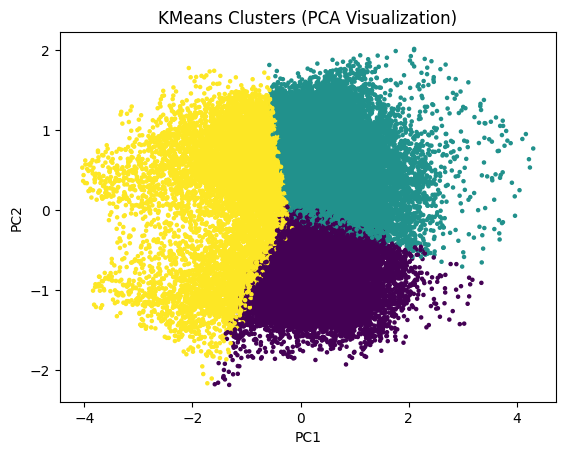

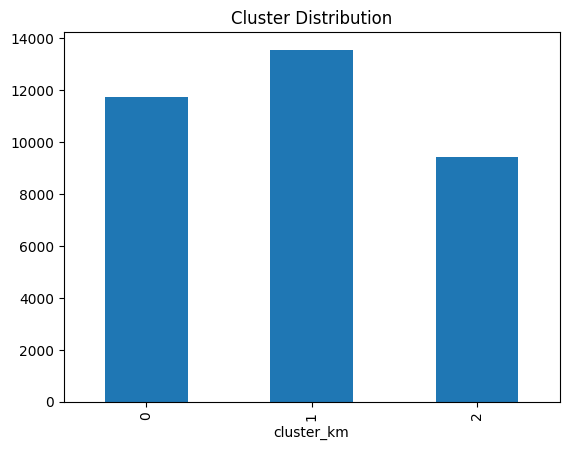


Cluster labeling done (for interpretation).


In [62]:
# -------------------------------
# 6. PCA visualization
# -------------------------------
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_cluster)

plt.figure()
plt.scatter(X_vis[:, 0], X_vis[:, 1],
            c=df_12h['cluster_km'], s=5)
plt.title("KMeans Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------------
# 7. Cluster distribution
# -------------------------------
df_12h['cluster_km'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Distribution")
plt.show()

# -------------------------------
# 8. Interpretation helper (optional but powerful)
# -------------------------------
def interpret_cluster(row):
    if row['demand_12h'] < df_12h['demand_12h'].quantile(0.33):
        return "Low Demand Regime"
    elif row['demand_12h'] < df_12h['demand_12h'].quantile(0.66):
        return "Medium Demand Regime"
    else:
        return "High Demand Regime"

df_12h['cluster_label'] = df_12h.apply(interpret_cluster, axis=1)

print("\nCluster labeling done (for interpretation).")

In [63]:
# ======================================================
# CLASSIFICATION FROM REGRESSION OUTPUTS
# ======================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n" + "="*60)
print("CLASSIFICATION FROM REGRESSION OUTPUTS")
print("="*60)

# --------------------------
# STEP 1: Regression predictions
# --------------------------
reg_pred_d = xgb_d.predict(X_test_d)
reg_pred_p = xgb_p.predict(X_test_p)

# --------------------------
# STEP 2: Define thresholds (from true data)
# --------------------------
d33, d66 = df_12h['demand_12h'].quantile([0.33, 0.66])
p33, p66 = df_12h['price_12h'].quantile([0.33, 0.66])

# Create the missing true class labels from the actual targets
# This is what the evaluation step was expecting.
def to_class(x, t1, t2):
    if x <= t1:
        return "Low"
    elif x <= t2:
        return "Medium"
    else:
        return "High"

df_12h['demand_class'] = df_12h['demand_12h'].apply(lambda x: to_class(x, d33, d66))
df_12h['price_class'] = df_12h['price_12h'].apply(lambda x: to_class(x, p33, p66))

# --------------------------
# STEP 3: Convert regression → classes
# --------------------------
reg_class_d = [to_class(x, d33, d66) for x in reg_pred_d]
reg_class_p = [to_class(x, p33, p66) for x in reg_pred_p]

# --------------------------
# STEP 4: True labels
# --------------------------
true_class_d = df_12h['demand_class'].iloc[split:]
true_class_p = df_12h['price_class'].iloc[split:]

# --------------------------
# STEP 5: Evaluation — DEMAND
# --------------------------
print("\nDEMAND (from regression → classification)\n")

print("Accuracy:", accuracy_score(true_class_d, reg_class_d))
print("\nConfusion Matrix:\n", confusion_matrix(true_class_d, reg_class_d))
print("\nClassification Report:\n")
print(classification_report(true_class_d, reg_class_d))

# --------------------------
# STEP 6: Evaluation — PRICE
# --------------------------
print("\nPRICE (from regression → classification)\n")

print("Accuracy:", accuracy_score(true_class_p, reg_class_p))
print("\nConfusion Matrix:\n", confusion_matrix(true_class_p, reg_class_p))
print("\nClassification Report:\n")
print(classification_report(true_class_p, reg_class_p))


CLASSIFICATION FROM REGRESSION OUTPUTS

DEMAND (from regression → classification)

Accuracy: 0.80682308910321

Confusion Matrix:
 [[1849   11  561]
 [   5 1908  286]
 [ 224  255 1848]]

Classification Report:

              precision    recall  f1-score   support

        High       0.89      0.76      0.82      2421
         Low       0.88      0.87      0.87      2199
      Medium       0.69      0.79      0.74      2327

    accuracy                           0.81      6947
   macro avg       0.82      0.81      0.81      6947
weighted avg       0.82      0.81      0.81      6947


PRICE (from regression → classification)

Accuracy: 0.7509716424355837

Confusion Matrix:
 [[3221   20 1014]
 [   1  631  215]
 [ 156  324 1365]]

Classification Report:

              precision    recall  f1-score   support

        High       0.95      0.76      0.84      4255
         Low       0.65      0.74      0.69       847
      Medium       0.53      0.74      0.62      1845

    accuracy      

In [64]:
import os
import pickle

print("\n" + "="*60)
print("SAVING CLEAN ARTIFACTS (NO PCA)")
print("="*60)

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -----------------------------
# 1. MODELS (REGRESSION)
# -----------------------------
models = {
    "demand_model.pkl": xgb_d,
    "price_model.pkl": xgb_p
}

# -----------------------------
# 2. SCALER (IMPORTANT)
# -----------------------------
scalers = {
    "scaler_demand.pkl": pca_scaler_d,
    "scaler_price.pkl": pca_scaler_p
}

# -----------------------------
# 3. FEATURES
# -----------------------------
features = {
    "demand_features.pkl": demand_features,
    "price_features.pkl": price_features
}

# -----------------------------
# 4. THRESHOLDS (FOR CLASSIFICATION)
# -----------------------------
thresholds = {
    "demand_thresholds.pkl": (d33, d66),
    "price_thresholds.pkl": (p33, p66)
}

# -----------------------------
# SAVE EVERYTHING
# -----------------------------
for name, obj in models.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in scalers.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in features.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

for name, obj in thresholds.items():
    with open(os.path.join(ARTIFACT_DIR, name), "wb") as f:
        pickle.dump(obj, f)

print("All artifacts saved successfully.")


SAVING CLEAN ARTIFACTS (NO PCA)


All artifacts saved successfully.


In [65]:
# ============================================================
# ANN - ARTIFICIAL NEURAL NETWORK (12-Hour Ahead Forecasting)
# ============================================================
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Features to use
ann_features = [
    'hour_sin', 'hour_cos',
    'demand_lag_1h', 'price_lag_1h',
    'renewable', 'fossil'
]

# Prepare data
df_ann = df.dropna(subset=ann_features + ['demand_12h', 'price_12h']).copy()

split = int(len(df_ann) * 0.8)

X_ann = df_ann[ann_features]
y_ann_demand = df_ann['demand_12h']
y_ann_price  = df_ann['price_12h']

X_train_ann = X_ann.iloc[:split]
X_test_ann  = X_ann.iloc[split:]
y_train_d_ann = y_ann_demand.iloc[:split]
y_test_d_ann  = y_ann_demand.iloc[split:]
y_train_p_ann = y_ann_price.iloc[:split]
y_test_p_ann  = y_ann_price.iloc[split:]

# Scale features (mandatory for ANN)
scaler_ann = StandardScaler()
X_train_ann_sc = scaler_ann.fit_transform(X_train_ann)
X_test_ann_sc  = scaler_ann.transform(X_test_ann)

# --- DEMAND ANN ---
ann_demand = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
print("Training ANN for DEMAND...")
ann_demand.fit(X_train_ann_sc, y_train_d_ann)
pred_ann_d = ann_demand.predict(X_test_ann_sc)
r2_ann_d   = r2_score(y_test_d_ann, pred_ann_d)
nmae_ann_d = mean_absolute_error(y_test_d_ann, pred_ann_d) / y_test_d_ann.mean()
print(f"[ANN | DEMAND] R2: {r2_ann_d:.4f} | NMAE: {nmae_ann_d:.4f}")

# --- PRICE ANN ---
ann_price = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)
print("Training ANN for PRICE...")
ann_price.fit(X_train_ann_sc, y_train_p_ann)
pred_ann_p = ann_price.predict(X_test_ann_sc)
r2_ann_p   = r2_score(y_test_p_ann, pred_ann_p)
nmae_ann_p = mean_absolute_error(y_test_p_ann, pred_ann_p) / y_test_p_ann.mean()
print(f"[ANN | PRICE]  R2: {r2_ann_p:.4f} | NMAE: {nmae_ann_p:.4f}")

# Save ANN artifacts
import pickle, os
os.makedirs('artifacts', exist_ok=True)
with open('artifacts/ann_demand.pkl', 'wb') as f: pickle.dump(ann_demand, f)
with open('artifacts/ann_price.pkl',  'wb') as f: pickle.dump(ann_price,  f)
with open('artifacts/ann_scaler.pkl', 'wb') as f: pickle.dump(scaler_ann, f)
print("ANN artifacts saved.")

Training ANN for DEMAND...
[ANN | DEMAND] R2: 0.6948 | NMAE: 0.0687
Training ANN for PRICE...
[ANN | PRICE]  R2: 0.4985 | NMAE: 0.1001
ANN artifacts saved.


In [66]:
# ============================================================
# MODEL RECOMMENDATION SYSTEM — FIXED
# Uses correct features/splits from cell 4, reuses trained models
# ============================================================
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

print("=" * 60)
print("   MODEL RECOMMENDATION SYSTEM (FIXED)")
print("=" * 60)

# ── Helper: train a fresh clone for price, then evaluate both ──
def evaluate_model(name, model_d, model_p,
                   Xtr_d, ytr_d, Xte_d, yte_d,
                   Xtr_p, ytr_p, Xte_p, yte_p,
                   pretrained=False):
    if not pretrained:
        model_d.fit(Xtr_d, ytr_d)
        model_p.fit(Xtr_p, ytr_p)

    preds_d = model_d.predict(Xte_d)
    preds_p = model_p.predict(Xte_p)

    r2_d   = r2_score(yte_d, preds_d)
    nmae_d = mean_absolute_error(yte_d, preds_d) / yte_d.mean()
    r2_p   = r2_score(yte_p, preds_p)
    nmae_p = mean_absolute_error(yte_p, preds_p) / yte_p.mean()

    return {
        "Model"       : name,
        "Demand R2"   : round(r2_d,   4),
        "Demand NMAE" : round(nmae_d, 4),
        "Price R2"    : round(r2_p,   4),
        "Price NMAE"  : round(nmae_p, 4),
        "Avg R2"      : round((r2_d + r2_p) / 2, 4),
    }

# ── Candidate models ──────────────────────────────────────────
# Baselines: train fresh with correct demand/price feature sets
fresh_candidates = {
    "Linear Regression" : (LinearRegression(),   LinearRegression()),
    "Bayesian Ridge"    : (BayesianRidge(),       BayesianRidge()),
    "KNN (k=5)"         : (KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
                            KNeighborsRegressor(n_neighbors=5, n_jobs=-1)),
    "Decision Tree"     : (DecisionTreeRegressor(max_depth=10, random_state=42),
                            DecisionTreeRegressor(max_depth=10, random_state=42)),
}

# Already-trained models from cells 8/9 — DO NOT retrain
pretrained_candidates = {
    "Random Forest" : (rf_d,   rf_p),
    "XGBoost"       : (xgb_d,  xgb_p),
}
if LGBM_AVAILABLE:
    pretrained_candidates["LightGBM"] = (lgbm_d, lgbm_p)

# ANN (trained on its own scaler/features — keep separate eval)
ann_entry = evaluate_model(
    "ANN",
    ann_demand, ann_price,
    X_train_ann_sc, y_train_d_ann, X_test_ann_sc, y_test_d_ann,
    X_train_ann_sc, y_train_p_ann, X_test_ann_sc, y_test_p_ann,
    pretrained=True
)

# ── Run evaluations ───────────────────────────────────────────
rec_results = []

for name, (md, mp) in fresh_candidates.items():
    rec_results.append(evaluate_model(
        name, md, mp,
        X_train_d, y_train_d, X_test_d, y_test_d,
        X_train_p, y_train_p, X_test_p, y_test_p,
        pretrained=False
    ))

for name, (md, mp) in pretrained_candidates.items():
    rec_results.append(evaluate_model(
        name, md, mp,
        X_train_d, y_train_d, X_test_d, y_test_d,
        X_train_p, y_train_p, X_test_p, y_test_p,
        pretrained=True   # skip refit, use results from cell 8
    ))

rec_results.append(ann_entry)

# ── Build & display table ─────────────────────────────────────
rec_df = (pd.DataFrame(rec_results)
            .sort_values("Avg R2", ascending=False)
            .reset_index(drop=True))
rec_df.index += 1   # rank from 1

print("\n--- FULL COMPARISON TABLE ---")
print(rec_df.to_string())

# ── Recommendation ────────────────────────────────────────────
best = rec_df.iloc[0]
print("\n" + "=" * 60)
print(f"  RECOMMENDED MODEL : {best['Model']}")
print(f"  Avg R2            : {best['Avg R2']}")
print(f"  Demand R2         : {best['Demand R2']}   NMAE: {best['Demand NMAE']}")
print(f"  Price  R2         : {best['Price R2']}   NMAE: {best['Price NMAE']}")
print("=" * 60)

rec_df.to_csv("artifacts/model_comparison.csv", index=False)
print("Saved → artifacts/model_comparison.csv")

   MODEL RECOMMENDATION SYSTEM (FIXED)

--- FULL COMPARISON TABLE ---
               Model  Demand R2  Demand NMAE  Price R2  Price NMAE  Avg R2
1           LightGBM     0.8197       0.0469    0.7282      0.0692  0.7739
2            XGBoost     0.8144       0.0480    0.7314      0.0687  0.7729
3      Random Forest     0.8102       0.0468    0.7214      0.0705  0.7658
4      Decision Tree     0.7421       0.0549    0.5943      0.0807  0.6682
5  Linear Regression     0.6389       0.0756    0.6809      0.0761  0.6599
6     Bayesian Ridge     0.6389       0.0756    0.6809      0.0761  0.6599
7                ANN     0.6948       0.0687    0.4985      0.1001  0.5967
8          KNN (k=5)     0.5460       0.0797   -1.1022      0.2135 -0.2781

  RECOMMENDED MODEL : LightGBM
  Avg R2            : 0.7739
  Demand R2         : 0.8197   NMAE: 0.0469
  Price  R2         : 0.7282   NMAE: 0.0692
Saved → artifacts/model_comparison.csv


In [67]:
from prefect import task, flow
import pandas as pd
import numpy as np
import pickle
import os

# =========================
# 1. LOAD DATA
# =========================
@task
def load_data(path="energy_dataset.csv"):
    df = pd.read_csv(path)
    df['time'] = pd.to_datetime(df['time'], utc=True)
    df = df.sort_values('time').set_index('time')
    return df


# =========================
# 2. FEATURE ENGINEERING
# =========================
@task
def preprocess(df):

    df['renewable'] = (
        df['generation solar'].fillna(0) +
        df['generation wind onshore'].fillna(0)
    )

    df['fossil'] = (
        df['generation fossil gas'].fillna(0) +
        df['generation fossil hard coal'].fillna(0)
    )

    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    df['demand_lag_1h'] = df['total load actual'].shift(1)
    df['price_lag_1h']  = df['price actual'].shift(1)

    df['demand_12h'] = df['total load actual'].shift(-12)
    df['price_12h']  = df['price actual'].shift(-12)

    df = df.dropna()

    return df


# =========================
# 3. TRAIN MODEL
# =========================
@task
def train_model(df):

    from xgboost import XGBRegressor

    features = [
        'hour_sin', 'hour_cos',
        'demand_lag_1h', 'price_lag_1h',
        'renewable', 'fossil'
    ]

    X = df[features]
    y_demand = df['demand_12h']
    y_price  = df['price_12h']

    model_d = XGBRegressor(n_estimators=200)
    model_p = XGBRegressor(n_estimators=200)

    model_d.fit(X, y_demand)
    model_p.fit(X, y_price)

    return model_d, model_p, features


# =========================
# 4. CREATE CLASSIFICATION THRESHOLDS
# =========================
@task
def create_thresholds(df):

    d33, d66 = df['demand_12h'].quantile([0.33, 0.66])
    p33, p66 = df['price_12h'].quantile([0.33, 0.66])

    return (d33, d66), (p33, p66)


# =========================
# 5. SAVE ARTIFACTS
# =========================
@task
def save_artifacts(model_d, model_p, features, d_th, p_th):

    os.makedirs("artifacts", exist_ok=True)

    artifacts = {
        "demand_model.pkl": model_d,
        "price_model.pkl": model_p,
        "features.pkl": features,
        "demand_thresholds.pkl": d_th,
        "price_thresholds.pkl": p_th
    }

    for name, obj in artifacts.items():
        with open(f"artifacts/{name}", "wb") as f:
            pickle.dump(obj, f)

    return "Saved successfully"


# =========================
# 6. MAIN FLOW
# =========================
@flow
def energy_pipeline():

    df = load_data()
    df = preprocess(df)

    model_d, model_p, features = train_model(df)
    d_th, p_th = create_thresholds(df)

    result = save_artifacts(model_d, model_p, features, d_th, p_th)

    return result


# RUN PIPELINE
if __name__ == "__main__":
    energy_pipeline()

11:36:45.451 | INFO    | Flow run 'scarlet-dolphin' - Beginning flow run 'scarlet-dolphin' for flow 'energy-pipeline'

11:36:46.202 | INFO    | Task run 'load_data-3ed' - Finished in state Completed()

11:36:46.398 | INFO    | Task run 'preprocess-052' - Finished in state Completed()

11:36:46.515 | INFO    | Task run 'train_model-0dd' - Finished in state Completed()

11:36:46.554 | INFO    | Task run 'create_thresholds-ad3' - Finished in state Completed()

11:36:46.609 | INFO    | Task run 'save_artifacts-cf8' - Finished in state Completed()

11:36:47.467 | INFO    | Flow run 'scarlet-dolphin' - Finished in state Completed()